# 01 - Modelado Avanzado: La Santa Trinidad del Boosting

Este notebook usa el dataset limpio de la Fase 2 (74 columnas puras) y entrena a los 3 gigantes del Machine Learning (XGBoost, LightGBM, CatBoost) para predecir la desnutrición crónica.

In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# 1. Cargar datos preprocesados de oro
# Ya no necesitamos hacer limpieza aquí, la Fase 2 entregó 74 columnas puras.
master = pd.read_parquet('../../data/processed/master_preprocessed.parquet')

print(f"Dataset de élite cargado. Filas: {len(master)} | Columnas: {master.shape[1]}")

Dataset de élite cargado. Filas: 285284 | Columnas: 74


In [3]:
# 2. Separar Features y Target
features = master.drop(columns=['TARGET_DESNUTRICION'])
target = master['TARGET_DESNUTRICION']

# Tipado Nativo para Árboles Modernos
for col in features.columns:
    if not pd.api.types.is_numeric_dtype(features[col]):
        # Rellenar vacíos explícitamente para CatBoost (solo en categóricas)
        features[col] = features[col].fillna('Desconocido')
        features[col] = features[col].astype(str).astype('category')

In [4]:
import sys
import os
import unicodedata

sys.path.append(os.path.abspath('../../')) 
from mnp.configs.column_labels import LABELS

# 3. Renombrar y Aplanar Columnas para LightGBM y XGBoost
features = features.rename(columns=LABELS)

clean_cols = []
for col in features.columns:
    col_str = unicodedata.normalize('NFKD', str(col)).encode('ASCII', 'ignore').decode('utf-8')
    col_str = re.sub(r'[^a-zA-Z0-9]+', '_', col_str).strip('_')
    clean_cols.append(col_str)
features.columns = clean_cols

print("Columnas renombradas y aplanadas. Ejemplo:")
print(features.columns[:5].tolist())

2026-06-16 20:09:30.508 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


Columnas renombradas y aplanadas. Ejemplo:
['HC1_Edad_en_meses', 'HC27_Sexo', 'HC56_Nivel_de_hemoglobina_ajustado_por_altitud', 'HC62_Ano_mas_alto_de_educacion_de_la_madre', 'HC63_Intervalo_de_nacimientos_anteriores_al_nino']


In [5]:
from sklearn.model_selection import train_test_split

# 4. División Estratificada Train/Test
# Como eliminamos 'year' en Fase 2 para evitar fugas, haremos un split 80/20 
# estratificando por el Target para mantener la proporción exacta de desnutridos.
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.20, random_state=42, stratify=target
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (228227, 73)
Test: (57057, 73)


Aplicando Undersampling solo a los datos de Train...
Train Original (Desbalanceado): (228227, 73)
Train Nuevo (Balanceado 50/50): (73346, 73)


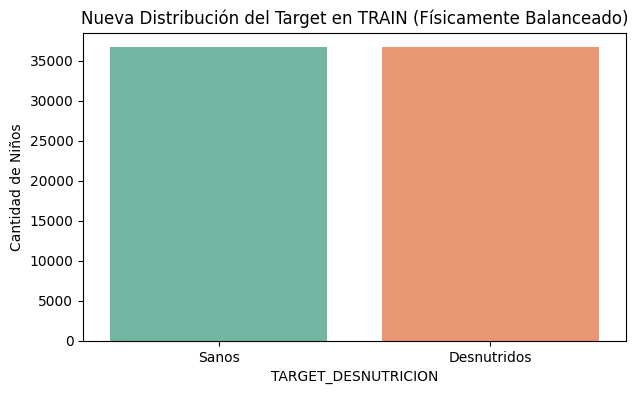

In [6]:
# 5. BALANCEO FÍSICO DE DATOS (Undersampling)
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns

print("Aplicando Undersampling solo a los datos de Train...")
rus = RandomUnderSampler(random_state=42)

X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print(f"Train Original (Desbalanceado): {X_train.shape}")
print(f"Train Nuevo (Balanceado 50/50): {X_train_resampled.shape}")

# Visualizamos el nuevo balance
plt.figure(figsize=(7, 4))
ax = sns.countplot(x=y_train_resampled, palette='Set2')
plt.title('Nueva Distribución del Target en TRAIN (Físicamente Balanceado)')
plt.xticks([0, 1], ['Sanos', 'Desnutridos'])
plt.ylabel('Cantidad de Niños')
plt.show()

In [7]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import time

# 6. ENTRENAMIENTO
cat_features = X_train_resampled.select_dtypes(include=['category']).columns.tolist()

models = {
    'XGBoost': xgb.XGBClassifier(
        random_state=42, 
        eval_metric='logloss', 
        enable_categorical=True
    ),
    'LightGBM': lgb.LGBMClassifier(
        random_state=42, 
        verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        random_state=42, 
        verbose=0
    )
}

trained_models = {}

for name, model in models.items():
    print(f"Entrenando {name} con datos 50/50...")
    start_time = time.time()
    
    if name == 'CatBoost':
        model.fit(X_train_resampled, y_train_resampled, cat_features=cat_features)
    else:
        model.fit(X_train_resampled, y_train_resampled)
        
    trained_models[name] = model
    print(f"[{name}] Completado en {time.time() - start_time:.2f} segundos.\n")

Entrenando XGBoost con datos 50/50...
[XGBoost] Completado en 1.40 segundos.

Entrenando LightGBM con datos 50/50...
[LightGBM] Completado en 1.04 segundos.

Entrenando CatBoost con datos 50/50...
[CatBoost] Completado en 97.77 segundos.



--- MÉTRICAS CON CLASES BALANCEADAS ---

==================== XGBoost ====================
➜ AUC-ROC Score: 0.8130
                 precision    recall  f1-score   support

      Sanos (0)       0.94      0.73      0.82     47889
Desnutridos (1)       0.35      0.75      0.47      9168

       accuracy                           0.73     57057
      macro avg       0.64      0.74      0.65     57057
   weighted avg       0.84      0.73      0.76     57057


==================== LightGBM ====================
➜ AUC-ROC Score: 0.8178
                 precision    recall  f1-score   support

      Sanos (0)       0.94      0.73      0.82     47889
Desnutridos (1)       0.35      0.76      0.48      9168

       accuracy                           0.73     57057
      macro avg       0.64      0.74      0.65     57057
   weighted avg       0.84      0.73      0.77     57057


==================== CatBoost ====================
➜ AUC-ROC Score: 0.8210
                 precision    recall  f1-sc

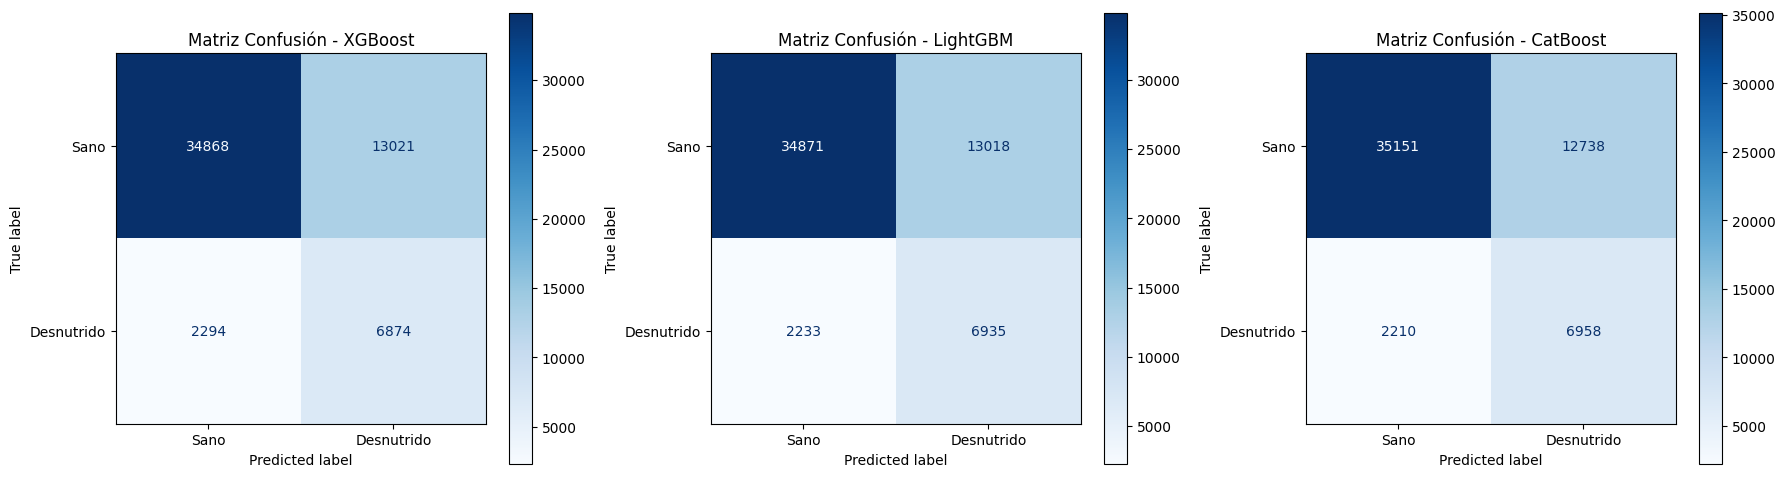

In [8]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- MÉTRICAS CON CLASES BALANCEADAS ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    print(f"\n==================== {name} ====================")
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    print(f"➜ AUC-ROC Score: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Sanos (0)', 'Desnutridos (1)']))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano', 'Desnutrido'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f"Matriz Confusión - {name}")

plt.tight_layout()
plt.show()

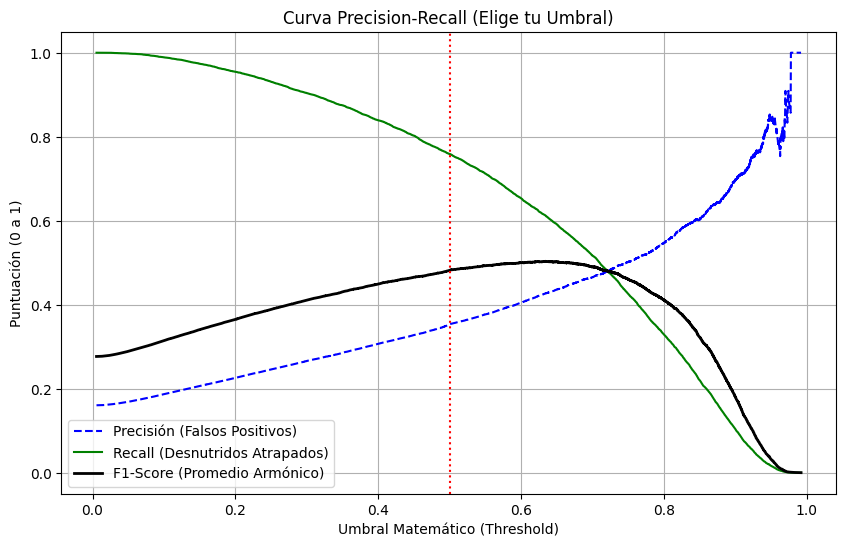

In [9]:
# 7. OPTIMIZACIÓN DEL UMBRAL (Threshold Tuning)
from sklearn.metrics import precision_recall_curve
import numpy as np

cb_model = trained_models['CatBoost']
y_probs = cb_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precisión (Falsos Positivos)')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Desnutridos Atrapados)')
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
plt.plot(thresholds, f1_scores, 'k-', linewidth=2, label='F1-Score (Promedio Armónico)')
plt.xlabel('Umbral Matemático (Threshold)')
plt.ylabel('Puntuación (0 a 1)')
plt.title('Curva Precision-Recall (Elige tu Umbral)')
plt.legend()
plt.axvline(x=0.5, color='r', linestyle=':', label='Umbral Fijo Actual (0.5)')
plt.grid(True)
plt.show()

In [13]:
# Queremos un Recall del 80% (Atrapar al 80% de los niños enfermos)
target_recall = 0.80

# Buscamos matemáticamente el umbral exacto que nos da ese Recall
idx = np.where(recalls[:-1] >= target_recall)[0][-1] 
umbral_ideal = thresholds[idx]

print(f"🎯 Para lograr un Recall de {target_recall*100}%:")
print(f"➜ Configura el modelo con este Umbral: {umbral_ideal:.4f}")
print(f"➜ A ese umbral, tu Precisión bajará a: {precisions[idx]:.4f}")


🎯 Para lograr un Recall de 80.0%:
➜ Configura el modelo con este Umbral: 0.4524
➜ A ese umbral, tu Precisión bajará a: 0.3289


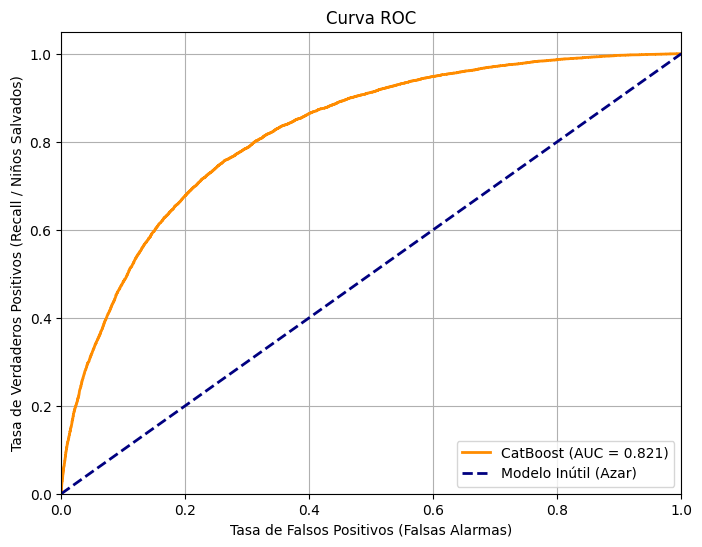

In [12]:
# 9. CURVA ROC (Receiver Operating Characteristic)
from sklearn.metrics import roc_curve, auc

# Calculamos los falsos positivos y verdaderos positivos para CatBoost
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'CatBoost (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Modelo Inútil (Azar)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Falsas Alarmas)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall / Niños Salvados)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Extrayendo Importancia de Variables del Mejor Modelo (CatBoost)


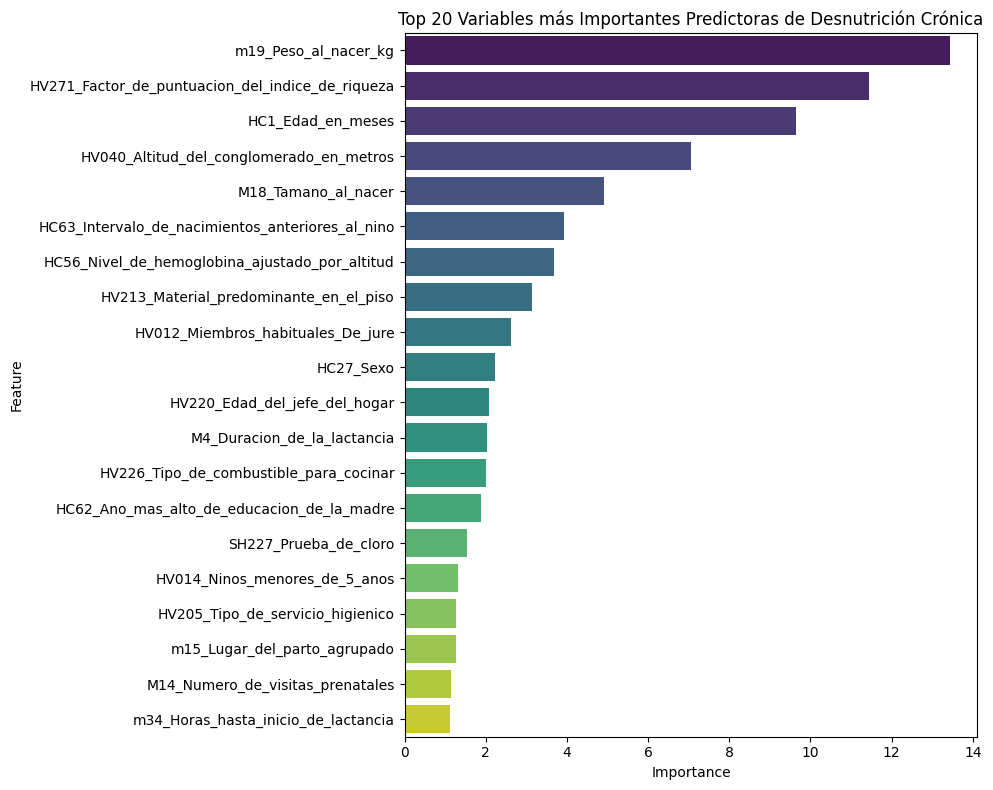

In [11]:
# 8. IMPORTANCIA DE VARIABLES (Insights Médicos/Sociales)
import seaborn as sns

print("Extrayendo Importancia de Variables del Mejor Modelo (CatBoost)")
cb_model = trained_models['CatBoost']

importances = cb_model.get_feature_importance()
feat_imp_df = pd.DataFrame({
    'Feature': X_train_resampled.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 20 Variables más Importantes Predictoras de Desnutrición Crónica')
plt.tight_layout()
plt.show()

--- MÉTRICAS CON UMBRAL MÉDICO (0.5) ---
                 precision    recall  f1-score   support

      Sanos (0)       0.94      0.73      0.82     47889
Desnutridos (1)       0.35      0.76      0.48      9168

       accuracy                           0.74     57057
      macro avg       0.65      0.75      0.65     57057
   weighted avg       0.85      0.74      0.77     57057



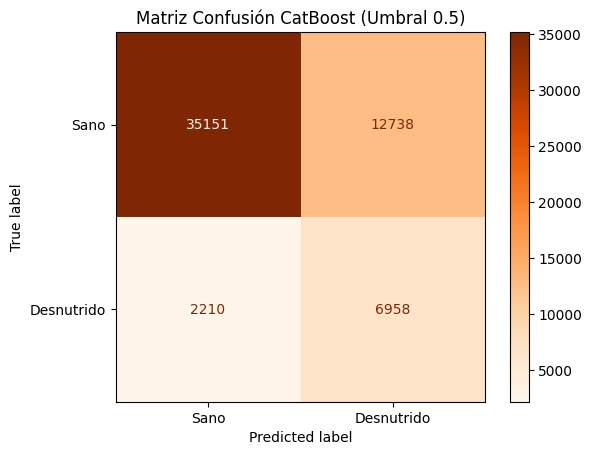

In [ ]:
# 10. EVALUACIÓN CON EL UMBRAL OPTIMIZADO
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# En lugar de usar el 0.5 por defecto, forzamos al modelo a usar nuestro umbral médico calculado.
umbral_medico = 0.4524
y_pred_optimo = (y_probs >= umbral_medico).astype(int)

print(f"--- MÉTRICAS CON UMBRAL MÉDICO ({umbral_medico}) ---")
print(classification_report(y_test, y_pred_optimo, target_names=['Sanos (0)', 'Desnutridos (1)']))

cm_opt = confusion_matrix(y_test, y_pred_optimo)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=['Sano', 'Desnutrido'])
disp.plot(cmap='Oranges', values_format='d')
plt.title(f'Matriz Confusión CatBoost (Umbral {umbral_medico})')
plt.show()


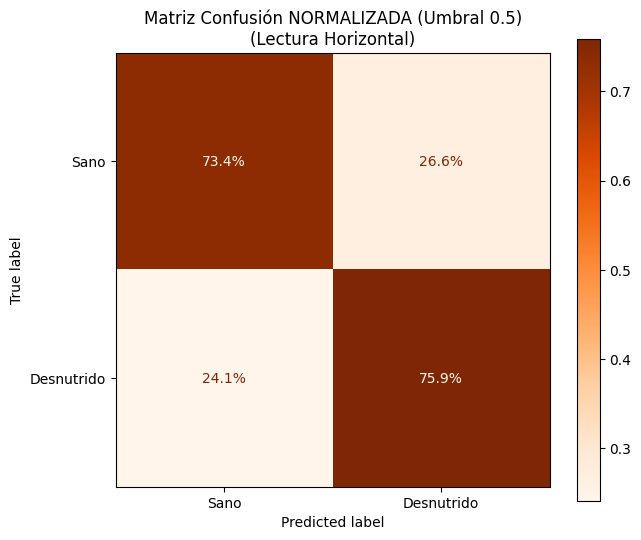

In [19]:
# 11. MATRIZ DE CONFUSIÓN NORMALIZADA (En Porcentajes)
# Mostrar la matriz normalizada (por filas) revela la verdadera eficacia del modelo (Recall)
# y elimina la ilusión óptica de la clase mayoritaria.

cm_opt_norm = confusion_matrix(y_test, y_pred_optimo, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_opt_norm, display_labels=['Sano', 'Desnutrido'])

fig, ax = plt.subplots(figsize=(7, 6))
disp_norm.plot(cmap='Oranges', values_format='.1%', ax=ax)
plt.title(f'Matriz Confusión NORMALIZADA (Umbral {umbral_medico})\n(Lectura Horizontal)')
plt.show()